In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

dane_normalne = pd.read_excel("Przebieg normalny.xlsx")
dane_zaburzone = pd.read_excel("Przebieg zaburzony.xlsx")


In [28]:
time = pd.to_datetime(dane_normalne["Time"])
dt = (time.iloc[1] - time.iloc[0]).total_seconds() # dt = 1

def przygotuj_sygnaly(df):
    temp_obiektu = df["y (T)"].values / 10.0
    temp_otoczenia = df["z (Tz)"].values / 10.0
    moc_grzalki = df["u (Pg)"].values
    return temp_obiektu, temp_otoczenia, moc_grzalki

y_norm, z_norm, u_norm = przygotuj_sygnaly(dane_normalne)
y_zab, z_zab, u_zab = przygotuj_sygnaly(dane_zaburzone)

In [48]:
# Zad 1 i 2: Wyznaczenie parametrów c i d metodą MNK
# Model dyskretny: y[n+1] = y[n] + (Δt/c)*u[n] + (d*Δt/c)*(z[n] - y[n])
# Równanie regresji:  y[n+1] -y[n] = a*u + b*(z-y)
# gdzie paramtery pomocnicze to: a = Δt/c, b = (d*Δt)/c

# wektor wyjścia Y = y[n+1] - y[n]
Y = y_norm[1:] - y_norm[:-1]
# macierz regresji Phi
Phi = np.column_stack((
    u_norm[:-1],
    z_norm[:-1] - y_norm[:-1]
))
# transpozycja macierzy Phi
Phi_T = Phi.T

# obliczenie iloczynu Phi^T * Phi
normal_matrix = Phi_T @ Phi

# odwrócenie macierzy (Phi^T Phi)^(-1)
normal_matrix_inv = np.linalg.inv(normal_matrix)

# obliczenie MNK 
theta = normal_matrix_inv @ Phi_T @ Y

# wyodrębnienie parametrów a i b
a_mnk = theta[0]
b_mnk = theta[1]

c = dt / a_mnk
d = b_mnk / a_mnk

print(f"Parametry pomocnicze modelu:")
print(f"a = {a_mnk:.10f}")
print(f"b = {b_mnk:.10f}")
print(f"Parametry modelu:")
print(f"c = {c:.4f}")
print(f"d = {d:.4f}")


Parametry pomocnicze modelu:
a = 0.0000394028
b = 0.0004157270
Parametry modelu:
c = 25378.8876
d = 10.5507


In [50]:
# zad 3: Predykcja z horyzontem h
def oblicz_predykcje(y_dane, u_dane, z_dane, a, b, horyzont):
    n_probek = len(y_dane)
    y_pred = np.full(n_probek, np.nan)
    
    #startujemy z rzeczywistego y[n-h] i wykonujemy h kroków modelem
    for n in range(horyzont, n_probek):
        y_n_minus_h = y_dane[n - horyzont]  #y[n-h]
        
        for k in range(horyzont):
            indeks = n - horyzont + k
            #jedna iteracja modelu dyskretnego
            y_n_minus_h = (
                y_n_minus_h
                + a * u_dane[indeks]
                + b * (z_dane[indeks] - y_n_minus_h)
            )
        
        y_pred[n] = y_n_minus_h  # ŷ[n]
    
    return y_pred

horyzonty = [ 1,5,10,30, 60]
wyniki_predykcji = {}  

for h in horyzonty:
    pred = oblicz_predykcje(
        y_norm,
        u_norm,
        z_norm,
        a_mnk,
        b_mnk,
        h
    )
    wyniki_predykcji[h] = pred

# for h in horyzonty:
#     y_predykowane = wyniki_predykcji[h]
# 
#     print(f"Predykcja wyjścia ŷ_n dla h = {h}")
#     print("n\tŷ_n")
# 
#     for n in range(h, len(y_predykowane)):
#         print(f"{n}\t{y_predykowane[n]:.3f}")

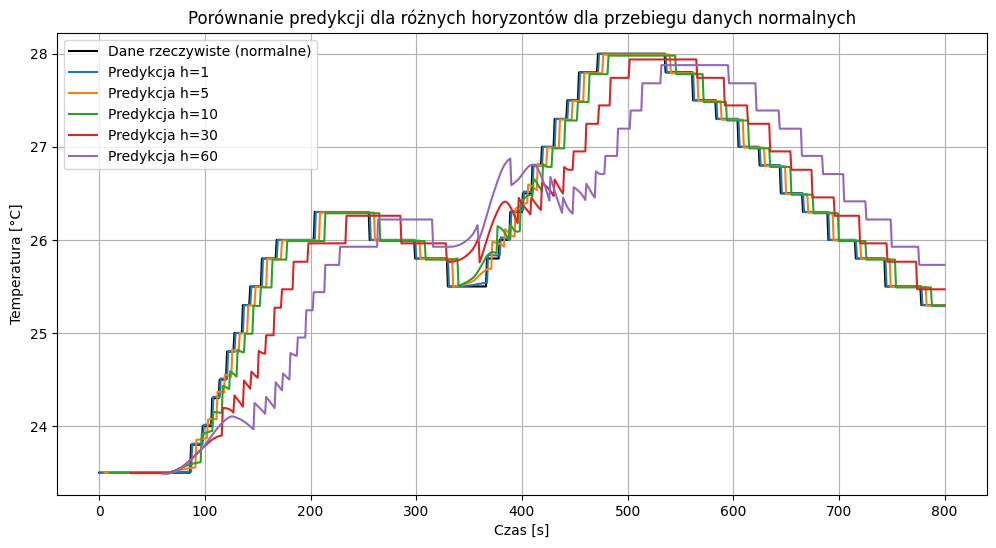

In [51]:
# przebieg rzeczywisty i przebiegi przewidywane -wykres porównawczy predykcji
plt.figure(figsize=(12, 6))
plt.plot(y_norm, label="Dane rzeczywiste (normalne)", color='black',  linewidth=1.5)
for h in horyzonty:
    plt.plot(wyniki_predykcji[h], label=f"Predykcja h={h}")
plt.title("Porównanie predykcji dla różnych horyzontów dla przebiegu danych normalnych")
plt.xlabel("Czas [s]")
plt.ylabel("Temperatura [°C]")
plt.legend()
plt.grid(True)
plt.show()

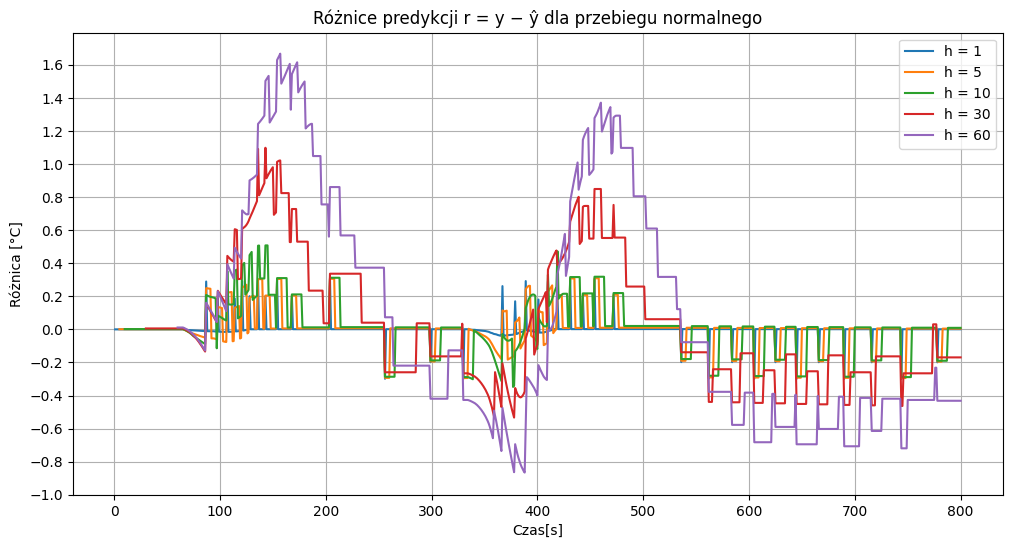

In [52]:
# CZĘŚĆ (ii)
# zad.1: reszty dla przebiegu normalnego 
reszty_normalne = {}

for h in horyzonty:
    y_pred = wyniki_predykcji[h]
    reszty_normalne[h] = y_norm - y_pred


plt.figure(figsize=(12, 6))
for h in horyzonty:
    plt.plot(reszty_normalne[h], label=f"h = {h}")
plt.title("Różnice predykcji r = y − ŷ dla przebiegu normalnego")
plt.xlabel("Czas[s]")
plt.yticks(np.arange(-1, 1.8, 0.2))
plt.ylabel("Różnica [°C]")
plt.legend()
plt.grid(True)
plt.show()

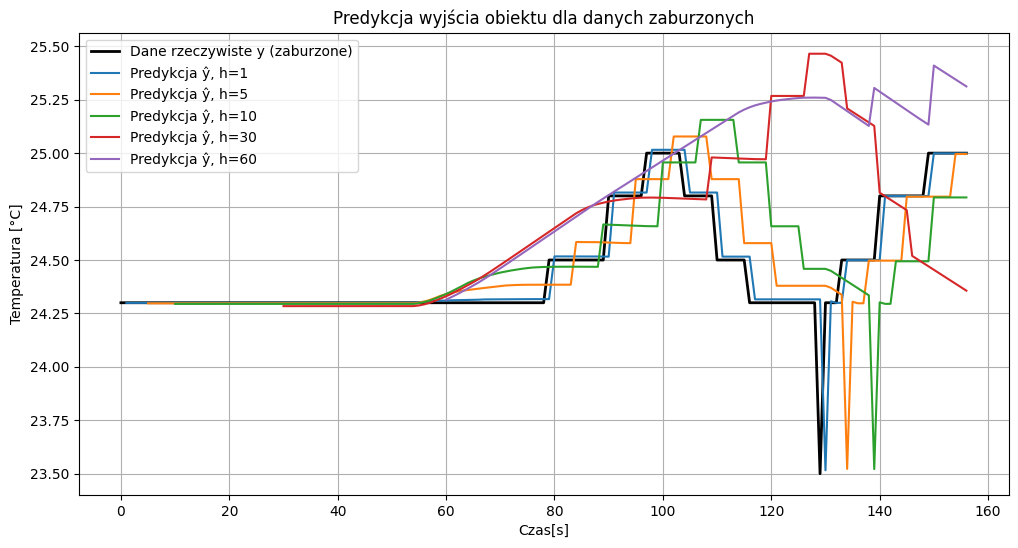

In [53]:
# zad.2: predykcja dla danych zaburzonych - dużo mniej próbek - tylko 157 gdzie w normalnym wynosiła ponad 800
predykcje_zaburzone = {}
reszty_zaburzone = {}

for h in horyzonty:
    y_pred_zab = oblicz_predykcje(y_zab, u_zab, z_zab, a_mnk, b_mnk, h)
    predykcje_zaburzone[h] = y_pred_zab
    reszty_zaburzone[h] = y_zab - y_pred_zab
    

plt.figure(figsize=(12, 6))
plt.plot(y_zab, label="Dane rzeczywiste y (zaburzone)", linewidth=2, color='black')

for h in horyzonty:
    plt.plot(predykcje_zaburzone[h], label=f"Predykcja ŷ, h={h}")

plt.title("Predykcja wyjścia obiektu dla danych zaburzonych")
plt.xlabel("Czas[s]")
plt.ylabel("Temperatura [°C]")
plt.legend()
plt.grid(True)
plt.show()

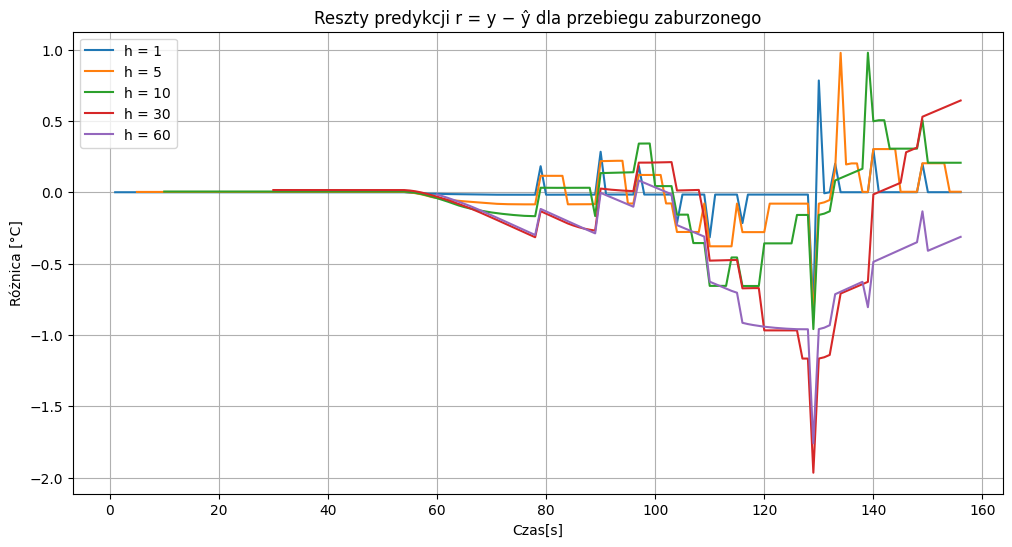

In [54]:
#Zad.3: reszty dla przebiegu zaburzonego
plt.figure(figsize=(12, 6))
for h in horyzonty:
    plt.plot(reszty_zaburzone[h], label=f"h = {h}")
plt.title("Reszty predykcji r = y − ŷ dla przebiegu zaburzonego")
plt.xlabel("Czas[s]")
plt.ylabel("Różnica [°C]")
plt.legend()
plt.grid(True)
plt.show()

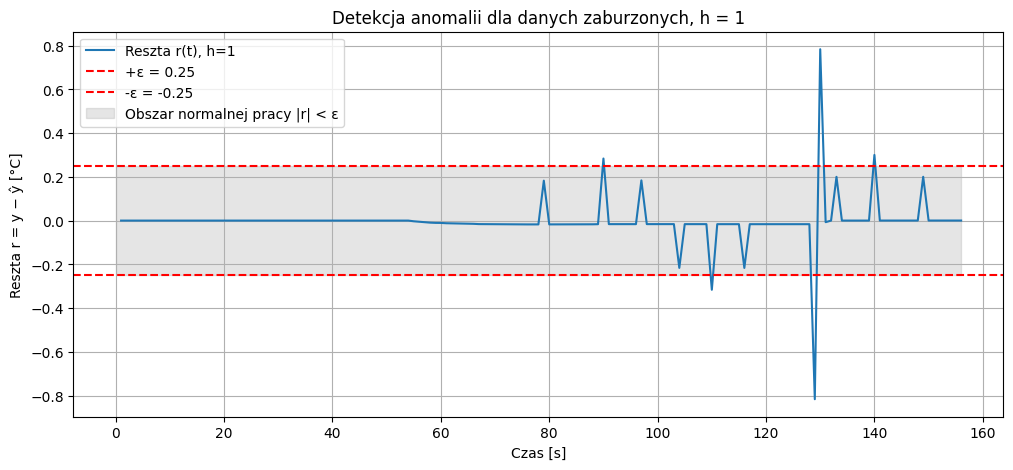

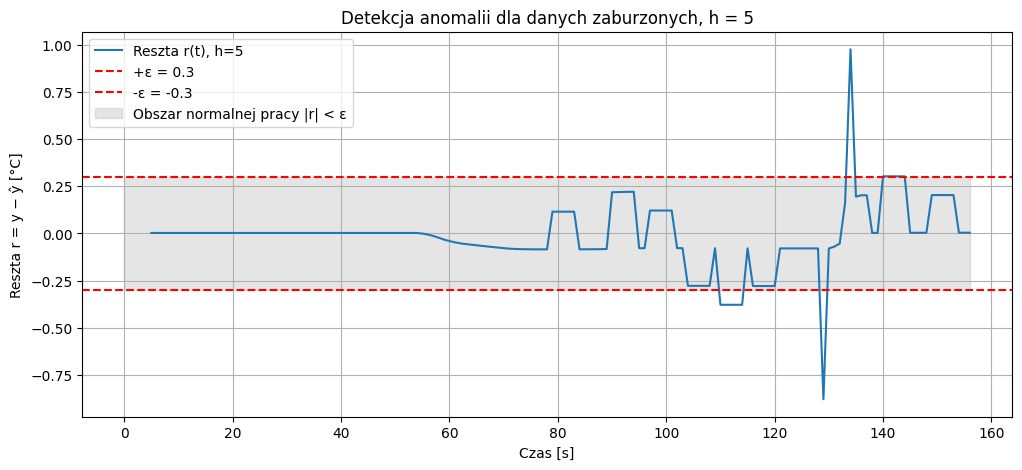

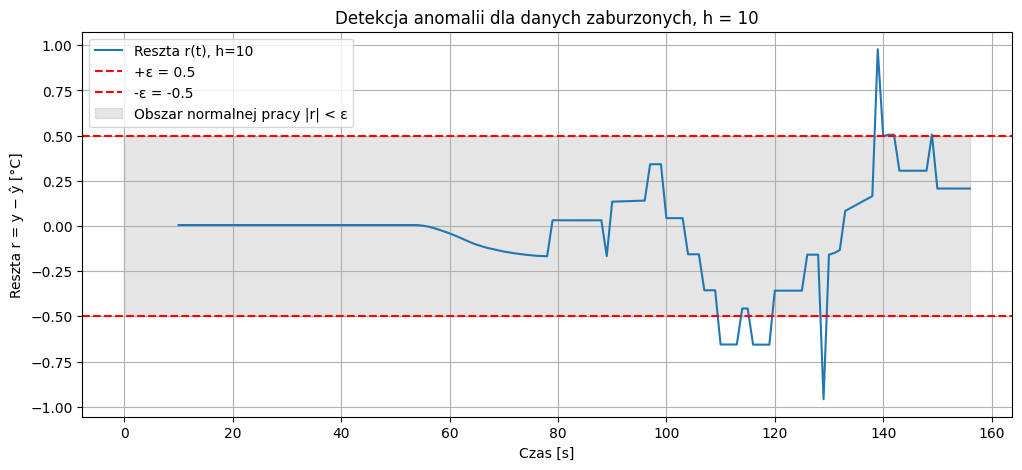

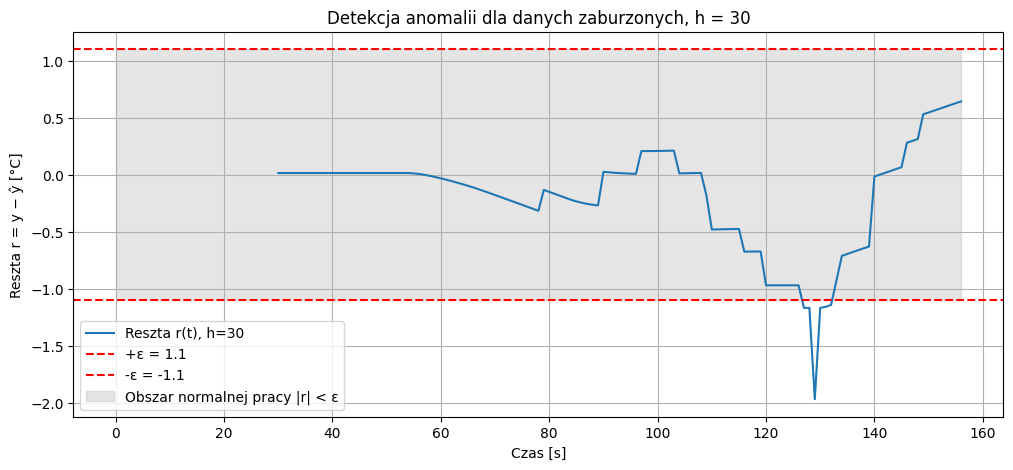

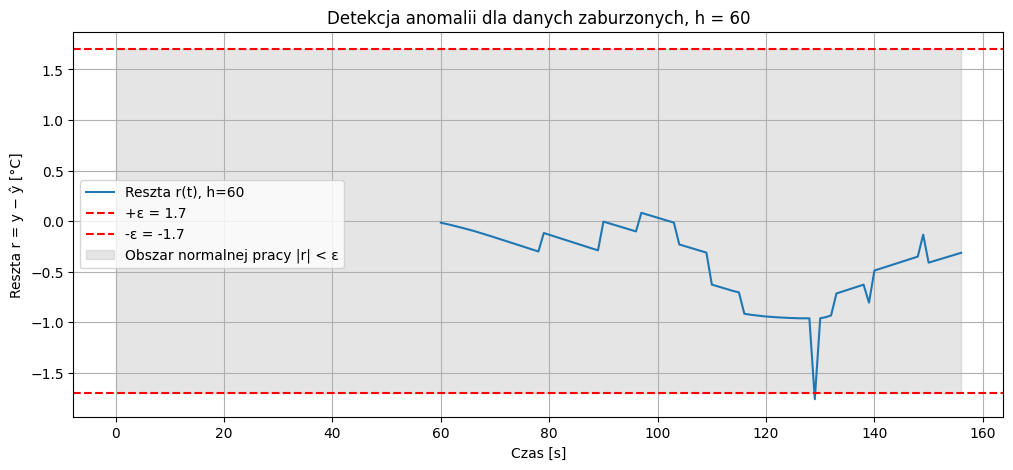

In [55]:
progi_epsilon = {
    1: 0.25,
    5: 0.30,
    10: 0.50,
    30: 1.10,
    60: 1.70
}
for h in horyzonty:
    r = reszty_zaburzone[h]
    epsilon = progi_epsilon[h]

    plt.figure(figsize=(12, 5))
    plt.plot(r, label=f"Reszta r(t), h={h}", linewidth=1.5)
    
    plt.axhline(epsilon, color='red', linestyle='--', label=f"+ε = {epsilon}")
    plt.axhline(-epsilon, color='red', linestyle='--', label=f"-ε = {-epsilon}")
    
    plt.fill_between(
        range(len(r)),
        -epsilon,
        epsilon,
        color='gray',
        alpha=0.2,
        label="Obszar normalnej pracy |r| < ε"
    )

    plt.title(f"Detekcja anomalii dla danych zaburzonych, h = {h}")
    plt.xlabel("Czas [s]")
    plt.ylabel("Reszta r = y − ŷ [°C]")
    plt.legend()
    plt.grid(True)
    plt.show()

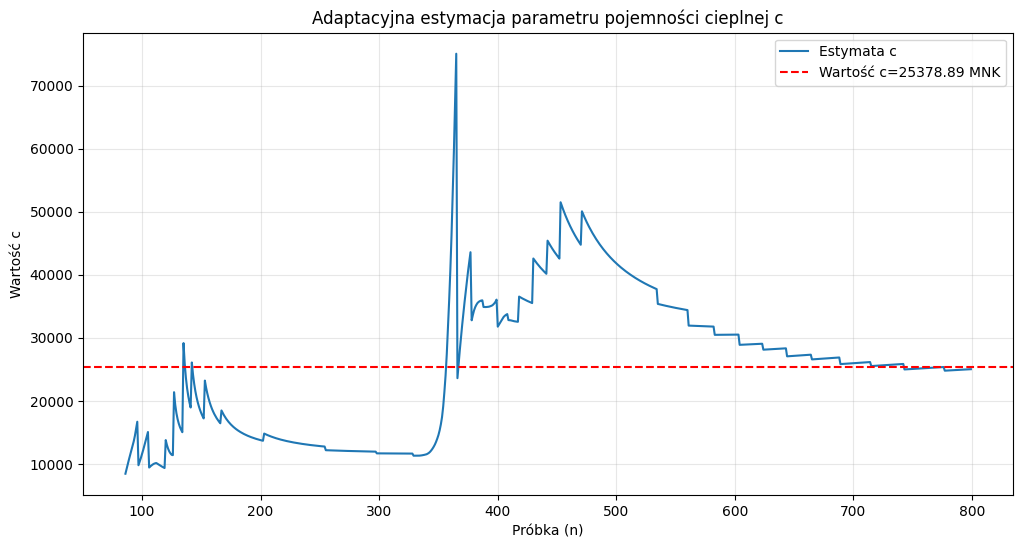

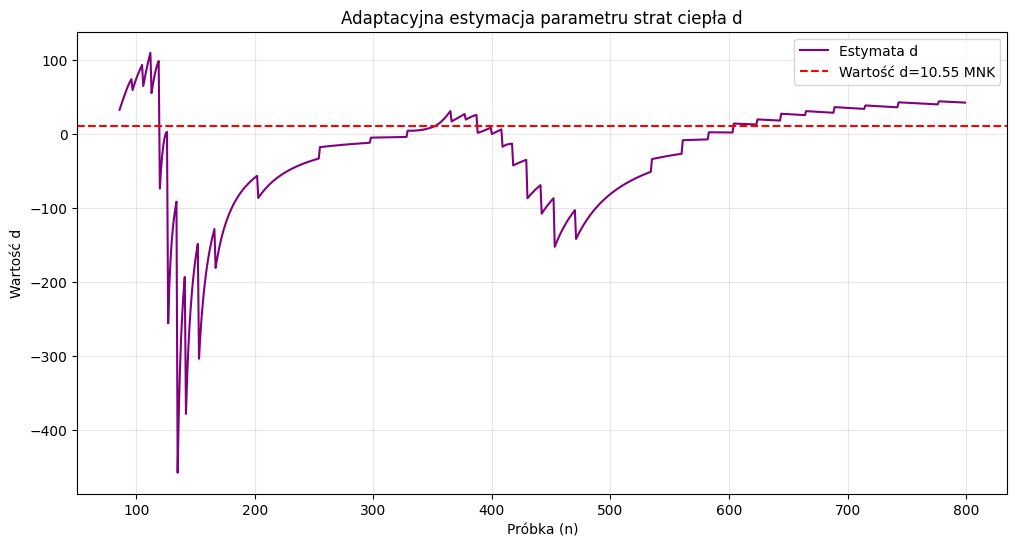

In [57]:
def algorytm_adaptacyjny(u, y, z, dt, lambda_f=0.995):
    N = len(y)

    # theta(0)=0, P(0)=duża wartość)
    theta = np.zeros(2)               # wektor parametrów [a, b]- zerami,  bez wiedzy wstępnej [a, b]^T
    P = np.eye(2) * 100000.0          # macierz kowariancji P (wysoka wartość = duża niepewność na start)

    historia_c = np.zeros(N-1)
    historia_d = np.zeros(N-1)

    for n in range(N - 1):
        #wektor regresji Phi - wejścia systemu
        phi = np.array([u[n], z[n] - y[n]])
        
        #rzeczywista zmiana wyjścia -pomiar
        y_skok_rzeczywisty = y[n+1] - y[n]

        #wyznaczenie wzmocnienia Kalmana - jak silnie nowy bład ma wpływać na zmianę parametrów
        #jak K jest duże to gwałtownie zmienia paramtry bo wie że jeszcze niewiele wie
        K = P @ phi / (lambda_f + phi.T @ P @ phi)
        
        #obliczenie błędu predykcji 
        blad = y_skok_rzeczywisty - phi.T @ theta
        
        #aktualizacja estymacje parametrów
        #nowy zestaw parametrów to stary zestaw plus poprawka wynikająca z błędu pomnożonego przez wzmocnienie
        theta = theta + K * blad
        
        #aktualizacja macierzy kowariancji P
        #skoro już nauczyliśmy się czegoś z nowej próbki, nasza niepewność P powinna zmaleć
        P = (P - np.outer(K, phi) @ P) / lambda_f # tworzy macierz poprawek na bazie wzmocnienia i wejsciowych sygnałów

        #wyznaczenie parametrów fizycznych c i d z aktualnych estymat a i b
        a_pred, b_pred = theta #theta[0] zostaje przypisane do zmiennej a_hat
        if abs(a_pred) > 1e-9:
            historia_c[n] = dt / a_pred
            historia_d[n] = b_pred / a_pred
        else:
            historia_c[n] = np.nan
            historia_d[n] = np.nan

    return historia_c, historia_d

c_rls, d_rls = algorytm_adaptacyjny(u_norm, y_norm, z_norm, dt)

plt.figure(figsize=(12, 6))
plt.plot(c_rls, label="Estymata c", linewidth=1.5)
plt.axhline(c, linestyle='--', color='red', label=f"Wartość c={c:.2f} MNK")
plt.title("Adaptacyjna estymacja parametru pojemności cieplnej c")
plt.xlabel("Próbka (n)")
plt.ylabel("Wartość c")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(d_rls, label="Estymata d", color='purple', linewidth=1.5)
plt.axhline(d, linestyle='--', color='red', label=f"Wartość d={d:.2f} MNK")
plt.title("Adaptacyjna estymacja parametru strat ciepła d")
plt.xlabel("Próbka (n)")
plt.ylabel("Wartość d")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()